# $(SASA) Models - Kmeans$

In [1]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pickle
import numpy as np
import pandas as pd

from pmbrl.model2 import Base_Line_Simple_Model
# from pmbrl.model2 import Model, Regularized_Reference_Loss
from pmbrl.data import Experiment_Data, get_data_expanded

In [2]:
data = Experiment_Data()

data.load(path='../training_data.csv')
data.build_training_dataset()

,step,episode,p,s,a,r,s_,a_,r_,s__
1929,10,77,"(0.1064004661572971, 0.3173964772630564)","(0.059, -0.385, -0.113, 0.579)",1,1.0,"(0.051, -0.18, -0.102, 0.062)",0.0,1.0,"(0.048, -0.381, -0.101, 0.472)"
1880,9,74,"(0.0909739944949207, 0.7220456982231811)","(0.009, -0.573, 0.056, 0.67)",1,1.0,"(-0.002, -0.383, 0.069, 0.481)",0.0,1.0,"(-0.01, -0.574, 0.079, 0.697)"
386,32,13,"(0.2403247570594251, 0.7298838219922094)","(0.051, -1.114, 0.04, 1.256)",0,1.0,"(0.029, -1.306, 0.065, 1.489)",1.0,1.0,"(0.002, -1.115, 0.095, 1.282)"
1741,15,69,"(0.1433033517266329, 1.8075969481187537)","(-0.047, -0.186, 0.077, 0.177)",1,1.0,"(-0.051, -0.001, 0.081, 0.101)",0.0,1.0,"(-0.051, -0.187, 0.083, 0.191)"
2304,8,91,"(0.1414757255992257, 0.302210744233297)","(-0.024, 0.44, 0.061, -0.81)",1,1.0,"(-0.015, 0.643, 0.044, -1.275)",1.0,1.0,"(-0.002, 0.847, 0.019, -1.751)"
...,...,...,...,...,...,...,...,...,...,...
2081,38,81,"(0.1825292152212203, 0.91730535067745)","(0.15, 0.331, 0.036, 0.097)",1,1.0,"(0.157, 0.52, 0.038, -0.066)",0.0,1.0,"(0.167, 0.33, 0.037, 0.111)"
2468,2,97,"(0.1358594884350926, 0.7069625486901497)","(0.013, -0.007, 0.008, 0.049)",1,1.0,"(0.013, 0.185, 0.009, -0.162)",0.0,1.0,"(0.017, -0.007, 0.006, 0.053)"
43,7,2,"(0.1598550005459618, 1.430854105014944)","(-0.068, -0.582, 0.051, 0.31)",0,1.0,"(-0.079, -0.768, 0.057, 0.423)",1.0,1.0,"(-0.095, -0.582, 0.066, 0.323)"
2053,10,81,"(0.1825292152212203, 0.91730535067745)","(-0.016, -0.032, 0.054, 0.092)",0,1.0,"(-0.017, -0.222, 0.056, 0.271)",1.0,1.0,"(-0.022, -0.033, 0.061, 0.112)"


In [3]:
expansions = {
    's': ['s0', 's1', 's2', 's3'],
    's_': ['s_0', 's_1', 's_2', 's_3'],
    'p': ['p0', 'p1'],
}

df = get_data_expanded(data.build_training_dataset(), expansions)
# df = df.loc[df['episode']<15].copy()
df

,step,episode,p,s,a,r,s_,a_,r_,s__,s0,s1,s2,s3,s_0,s_1,s_2,s_3,p0,p1
954,39,38,"(0.4545373771214862, 0.5810082803318615)","(0.139, 1.333, -0.053, -1.871)",1,1.0,"(0.166, 1.531, -0.09, -2.229)",1.0,1.0,"(0.197, 1.729, -0.135, -2.599)",0.139,1.333,-0.053,-1.871,0.166,1.531,-0.090,-2.229,0.454537,0.581008
1597,19,65,"(0.1785778102029531, 1.438381745613701)","(0.034, 0.192, -0.076, -0.204)",1,1.0,"(0.038, 0.379, -0.08, -0.32)",0.0,1.0,"(0.046, 0.192, -0.086, -0.222)",0.034,0.192,-0.076,-0.204,0.038,0.379,-0.080,-0.320,0.178578,1.438382
1761,35,69,"(0.1433033517266329, 1.8075969481187537)","(0.152, 0.921, 0.054, -0.174)",0,1.0,"(0.17, 0.735, 0.05, -0.086)",1.0,1.0,"(0.185, 0.92, 0.049, -0.165)",0.152,0.921,0.054,-0.174,0.170,0.735,0.050,-0.086,0.143303,1.807597
2324,11,92,"(0.1771043759930183, 0.8300521931250568)","(-0.018, -0.612, -0.003, 0.513)",1,1.0,"(-0.03, -0.422, 0.007, 0.326)",0.0,1.0,"(-0.039, -0.612, 0.014, 0.514)",-0.018,-0.612,-0.003,0.513,-0.030,-0.422,0.007,0.326,0.177104,0.830052
1882,11,74,"(0.0909739944949207, 0.7220456982231811)","(-0.01, -0.574, 0.079, 0.697)",1,1.0,"(-0.021, -0.384, 0.093, 0.513)",1.0,1.0,"(-0.029, -0.194, 0.103, 0.333)",-0.010,-0.574,0.079,0.697,-0.021,-0.384,0.093,0.513,0.090974,0.722046
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
432,0,17,"(0.6997930397279742, 0.1120270074190065)","(0.035, -0.034, 0.006, -0.013)",0,1.0,"(0.034, -0.322, 0.006, 2.329)",0.0,1.0,"(0.027, -0.61, 0.052, 4.671)",0.035,-0.034,0.006,-0.013,0.034,-0.322,0.006,2.329,0.699793,0.112027
417,13,15,"(0.4832980502500528, 0.5461494126807303)","(0.012, 0.232, -0.005, -0.457)",1,1.0,"(0.017, 0.431, -0.014, -0.832)",1.0,1.0,"(0.025, 0.63, -0.031, -1.21)",0.012,0.232,-0.005,-0.457,0.017,0.431,-0.014,-0.832,0.483298,0.546149
1332,1,55,"(0.8034667051045895, 0.8611481301108855)","(0.034, 0.235, -0.029, -0.387)",0,1.0,"(0.039, 0.038, -0.036, -0.048)",0.0,1.0,"(0.039, -0.159, -0.037, 0.287)",0.034,0.235,-0.029,-0.387,0.039,0.038,-0.036,-0.048,0.803467,0.861148
1152,50,46,"(0.5759890361457483, 0.539204361971833)","(-0.281, -0.033, 0.134, -0.203)",1,1.0,"(-0.282, 0.165, 0.13, -0.551)",0.0,1.0,"(-0.278, -0.038, 0.119, -0.085)",-0.281,-0.033,0.134,-0.203,-0.282,0.165,0.130,-0.551,0.575989,0.539204


# Initialization by Random Partitioning

In [4]:
k = 5
models = [Base_Line_Simple_Model() for _ in range(k)]

In [5]:
groups = np.random.randint(low=0, high=k, size=df.episode.unique().shape[0])
df['group'] = np.nan

for i, g in enumerate(groups):
    df.loc[df['episode']==i,'group'] = g
df

,step,episode,p,s,a,r,s_,a_,r_,s__,...,s1,s2,s3,s_0,s_1,s_2,s_3,p0,p1,group
954,39,38,"(0.4545373771214862, 0.5810082803318615)","(0.139, 1.333, -0.053, -1.871)",1,1.0,"(0.166, 1.531, -0.09, -2.229)",1.0,1.0,"(0.197, 1.729, -0.135, -2.599)",...,1.333,-0.053,-1.871,0.166,1.531,-0.090,-2.229,0.454537,0.581008,0.0
1597,19,65,"(0.1785778102029531, 1.438381745613701)","(0.034, 0.192, -0.076, -0.204)",1,1.0,"(0.038, 0.379, -0.08, -0.32)",0.0,1.0,"(0.046, 0.192, -0.086, -0.222)",...,0.192,-0.076,-0.204,0.038,0.379,-0.080,-0.320,0.178578,1.438382,0.0
1761,35,69,"(0.1433033517266329, 1.8075969481187537)","(0.152, 0.921, 0.054, -0.174)",0,1.0,"(0.17, 0.735, 0.05, -0.086)",1.0,1.0,"(0.185, 0.92, 0.049, -0.165)",...,0.921,0.054,-0.174,0.170,0.735,0.050,-0.086,0.143303,1.807597,2.0
2324,11,92,"(0.1771043759930183, 0.8300521931250568)","(-0.018, -0.612, -0.003, 0.513)",1,1.0,"(-0.03, -0.422, 0.007, 0.326)",0.0,1.0,"(-0.039, -0.612, 0.014, 0.514)",...,-0.612,-0.003,0.513,-0.030,-0.422,0.007,0.326,0.177104,0.830052,1.0
1882,11,74,"(0.0909739944949207, 0.7220456982231811)","(-0.01, -0.574, 0.079, 0.697)",1,1.0,"(-0.021, -0.384, 0.093, 0.513)",1.0,1.0,"(-0.029, -0.194, 0.103, 0.333)",...,-0.574,0.079,0.697,-0.021,-0.384,0.093,0.513,0.090974,0.722046,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
432,0,17,"(0.6997930397279742, 0.1120270074190065)","(0.035, -0.034, 0.006, -0.013)",0,1.0,"(0.034, -0.322, 0.006, 2.329)",0.0,1.0,"(0.027, -0.61, 0.052, 4.671)",...,-0.034,0.006,-0.013,0.034,-0.322,0.006,2.329,0.699793,0.112027,1.0
417,13,15,"(0.4832980502500528, 0.5461494126807303)","(0.012, 0.232, -0.005, -0.457)",1,1.0,"(0.017, 0.431, -0.014, -0.832)",1.0,1.0,"(0.025, 0.63, -0.031, -1.21)",...,0.232,-0.005,-0.457,0.017,0.431,-0.014,-0.832,0.483298,0.546149,1.0
1332,1,55,"(0.8034667051045895, 0.8611481301108855)","(0.034, 0.235, -0.029, -0.387)",0,1.0,"(0.039, 0.038, -0.036, -0.048)",0.0,1.0,"(0.039, -0.159, -0.037, 0.287)",...,0.235,-0.029,-0.387,0.039,0.038,-0.036,-0.048,0.803467,0.861148,4.0
1152,50,46,"(0.5759890361457483, 0.539204361971833)","(-0.281, -0.033, 0.134, -0.203)",1,1.0,"(-0.282, 0.165, 0.13, -0.551)",0.0,1.0,"(-0.278, -0.038, 0.119, -0.085)",...,-0.033,0.134,-0.203,-0.282,0.165,0.130,-0.551,0.575989,0.539204,2.0


## Initial Training 

In [6]:
def train_models(models, train_dataset):
    train_data = [None for _ in models]

    for g, model in enumerate(models):
        # print('train model: ', g)
        group_data = train_dataset.loc[train_dataset['group']==g]
        x, y = model.get_features_targets(group_data)
        trainer = model.train(x, y, num_epochs=1000)
        train_data[g] = data.get_training_data(trainer, inference_schema=model.inference_schema)
    
    return train_data


In [7]:
train_data = train_models(models, df[[
    's', 's_', 's__', 'a', 'a_', 'r', 'p', 'group'
]])

train_data[0].head()

,epoch,mse_s,transition,reward
0,0,"[0.04742252826690674, 0.37675365805625916, 0.2...",1.433168,2.245065
1,1,"[0.04666261374950409, 0.3738597631454468, 0.23...",1.419849,2.239466
2,2,"[0.04591471329331398, 0.3709816038608551, 0.22...",1.406661,2.233929
3,3,"[0.045179225504398346, 0.3681187629699707, 0.2...",1.393603,2.228450
4,4,"[0.04445672780275345, 0.3652707040309906, 0.21...",1.380676,2.223030


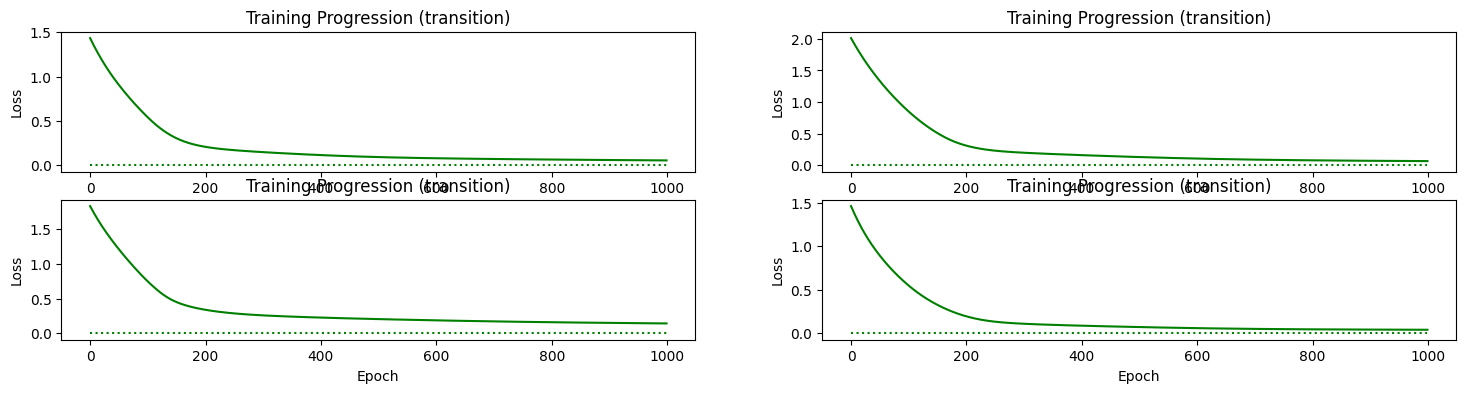

In [8]:
fig, axs = plt.subplots(2, 2, figsize=(18, 4))

data.plot_training_loss(axs[0][0], train_data[0].transition)
data.plot_training_loss(axs[0][1], train_data[1].transition)
data.plot_training_loss(axs[1][0], train_data[2].transition)
data.plot_training_loss(axs[1][1], train_data[3].transition)

plt.show()

# Predict 

In [9]:
def evaluate(models, df):
    def predict(model):
        prediction_dataset = df.copy()
        prediction_dataset[model.grouped_targets_lables] = prediction_dataset.apply(lambda row: data._predict_from_row(row, model), axis=1, result_type='expand')
        return prediction_dataset

    predictions = [predict(m) for m in models]

    prediction_dataset = df.copy()
    for i, pred in enumerate(predictions):
        prediction_dataset[f'estimated_s_model_{i}'] = pred['estimated_s']
        
        results = data.get_evaluation_metrics(pred, p=False)
        prediction_dataset[f'rse_model_{i}'] = results['rse']
        prediction_dataset[f'rse_normalized_model_{i}'] = results['rse_normalized']

        prediction_dataset[f'rse_s0_model_{i}'] = results['rse_s0']
        prediction_dataset[f'rse_s1_model_{i}'] = results['rse_s1']
        prediction_dataset[f'rse_s2_model_{i}'] = results['rse_s2']
        prediction_dataset[f'rse_s3_model_{i}'] = results['rse_s3']

        prediction_dataset[f'rse_s0_normalized_model_{i}'] = results['rse_s0_normalized']
        prediction_dataset[f'rse_s1_normalized_model_{i}'] = results['rse_s1_normalized']
        prediction_dataset[f'rse_s2_normalized_model_{i}'] = results['rse_s2_normalized']
        prediction_dataset[f'rse_s3_normalized_model_{i}'] = results['rse_s3_normalized']


    return prediction_dataset

In [10]:
prediction_dataset = evaluate(models, df)
prediction_dataset.head()

,step,episode,p,s,a,r,s_,a_,r_,s__,...,rse_model_4,rse_normalized_model_4,rse_s0_model_4,rse_s1_model_4,rse_s2_model_4,rse_s3_model_4,rse_s0_normalized_model_4,rse_s1_normalized_model_4,rse_s2_normalized_model_4,rse_s3_normalized_model_4
954,39,38,"(0.4545373771214862, 0.5810082803318615)","(0.139, 1.333, -0.053, -1.871)",1,1.0,"(0.166, 1.531, -0.09, -2.229)",1.0,1.0,"(0.197, 1.729, -0.135, -2.599)",...,0.732,0.502401,0.011,0.260,0.016,0.445,0.407993,0.464367,0.537170,0.600072
1597,19,65,"(0.1785778102029531, 1.438381745613701)","(0.034, 0.192, -0.076, -0.204)",1,1.0,"(0.038, 0.379, -0.08, -0.32)",0.0,1.0,"(0.046, 0.192, -0.086, -0.222)",...,0.121,0.494293,0.048,0.018,0.024,0.031,0.423397,0.422199,0.556355,0.575219
1761,35,69,"(0.1433033517266329, 1.8075969481187537)","(0.152, 0.921, 0.054, -0.174)",0,1.0,"(0.17, 0.735, 0.05, -0.086)",1.0,1.0,"(0.185, 0.92, 0.049, -0.165)",...,0.339,0.488989,0.069,0.123,0.001,0.146,0.432140,0.440495,0.501199,0.582123
2324,11,92,"(0.1771043759930183, 0.8300521931250568)","(-0.018, -0.612, -0.003, 0.513)",1,1.0,"(-0.03, -0.422, 0.007, 0.326)",0.0,1.0,"(-0.039, -0.612, 0.014, 0.514)",...,0.160,0.485935,0.006,0.061,0.013,0.080,0.405912,0.429692,0.529976,0.578161
1882,11,74,"(0.0909739944949207, 0.7220456982231811)","(-0.01, -0.574, 0.079, 0.697)",1,1.0,"(-0.021, -0.384, 0.093, 0.513)",1.0,1.0,"(-0.029, -0.194, 0.103, 0.333)",...,0.087,0.488867,0.061,0.010,0.014,0.002,0.428809,0.420805,0.532374,0.573478


In [11]:
def reagroup(prediction_dataset):
    agg_results = prediction_dataset[['episode'] + [
    f'rse_model_{i}' for i,_ in enumerate(models)
    #     'rse_model_0',
    #     'rse_model_1',
    #     'rse_model_2',
    #     'rse_model_3',
    #     'rse_model_4',
    ]].groupby('episode').mean().reset_index()

    agg_results['best_model'] = agg_results.apply(lambda row: np.argmin(row[1:].values), axis=1)
    print(agg_results['best_model'].value_counts())

    prediction_dataset['best_model'] = prediction_dataset.apply(lambda row: agg_results[agg_results['episode']==row['episode']].best_model.values[0],axis=1)
    prediction_dataset['best_rse'] = prediction_dataset.apply(lambda row: row[f'rse_model_{row.best_model}'],axis=1)

    return prediction_dataset

In [12]:
prediction_dataset = reagroup(prediction_dataset)
prediction_dataset[['best_rse']].describe()

best_model
0    37
2    34
1    14
4     8
3     7
Name: count, dtype: int64


,best_rse
count,2504.000000
mean,0.185244
std,0.237264
min,0.005000
25%,0.082000
50%,0.136000
75%,0.212250
max,4.858000


# LOOP

In [13]:

# while True: 
for _ in range(10): 
    check = prediction_dataset[prediction_dataset['group'] != prediction_dataset['best_model']].shape[0]
    print(f'epis_changed: {check}')
    if check == 0:
        break
    

    train_df = prediction_dataset[['s', 's_', 's__', 'a', 'a_', 'r', 'p']].copy()
    train_df['group'] = prediction_dataset['best_model']
    train_data = train_models(models, train_df)

    prediction_dataset = evaluate(models, prediction_dataset)

    prediction_dataset = reagroup(prediction_dataset)
    print(prediction_dataset[['best_rse']].mean())
    

epis_changed: 1400
best_model
0    36
1    25
2    24
4    11
3     4
Name: count, dtype: int64
best_rse    0.113628
dtype: float64
epis_changed: 1634
best_model
1    35
0    32
2    18
4    11
3     4
Name: count, dtype: int64
best_rse    0.08168
dtype: float64
epis_changed: 1743
best_model
1    37
0    31
2    17
4    11
3     4
Name: count, dtype: int64
best_rse    0.064419
dtype: float64
epis_changed: 1743
best_model
1    37
0    31
2    17
4    11
3     4
Name: count, dtype: int64
best_rse    0.057647
dtype: float64
epis_changed: 1743
best_model
1    37
0    31
2    17
4    11
3     4
Name: count, dtype: int64
best_rse    0.052513
dtype: float64
epis_changed: 1743
best_model
1    37
0    31
2    17
4    11
3     4
Name: count, dtype: int64
best_rse    0.048316
dtype: float64
epis_changed: 1743
best_model
1    37
0    31
2    17
4    11
3     4
Name: count, dtype: int64
best_rse    0.045502
dtype: float64
epis_changed: 1743
best_model
1    38
0    31
2    16
4    11
3     4
Name: c